In [1]:
#---------------------------------------------------------------------
# setup Python environments
#---------------------------------------------------------------------
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt   # module for plotting
plt.style.use("ggplot")
import numpy as np                # module for vectorized numeric calculation
import sys
sys.path.append("../")
from src.Structure import AtomCls
from src.Atomic import LTELib, ColExcite, SEsolver
from src.RadiativeTransfer import Thin
from src import Constants as Cst

In [2]:
#--------------------------------------------------------------------------
# hydrogen population
#--------------------------------------------------------------------------
chi_Hm = 0.754 *Cst.eV2erg_ 
chi_HI = 13.6 *Cst.eV2erg_
chi_n2 = chi_HI *(1.-1./(2**2))
T = np.array([2,3,4])*1000
u = LTELib.Ufunc('Mg_I',T)
u

array([ 1.00450542,  1.00164709,  0.99814887])

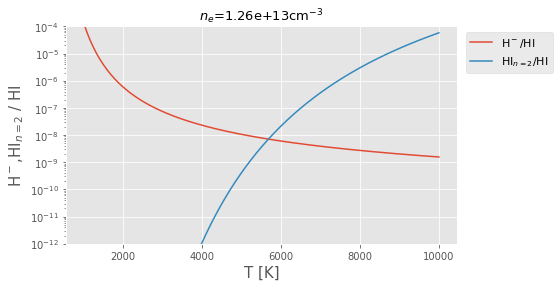

In [3]:
#--------------------------------------------------------------------------
# abundance of negative hydrogen 
#--------------------------------------------------------------------------
chi_Hm = 0.754 *Cst.eV2erg_ 
chi_HI = 13.6 *Cst.eV2erg_
chi_n2 = chi_HI *(1.-1./(2**2))
#T = np.logspace(3, 4, 301)     # temperature in K,  10^3 - 10^5 K
T = np.linspace(1000, 10000, 301)     # temperature in K,  10^3 - 10^5 K
n_e = np.logspace(11,17,201)    # electron density, cm-3
nT = T.shape[0]
nn = len(n_e) # n_e.shape[0] also work
Hm_HI = np.zeros([nn,nT])
n2_HI = np.zeros([nn,nT])
for i in range(nn):
        Hm_HI[i,:] = 1./LTELib.Saha_distribution(1,4,chi_Hm,n_e[i],T)
        n2_HI[i,:] = LTELib.Boltzmann_distribution(2,16,chi_n2,T)
i=70
fig, ax = plt.subplots(1,1, figsize=(7,4)) #, dpi=150)
ax.plot(T,Hm_HI[i,:],label="H$^-$/HI")
ax.plot(T,n2_HI[i,:],label="HI$_{n=2}$/HI")
ax.set_xlabel("T [K]",fontsize=15)
ax.set_yscale("log")
ax.set_ylabel("H$^-$,HI$_{n=2}$ / HI",fontsize=15)
ax.set_ylim(1e-12,1e-4)
#plt.title("$n_e$="+str(n_e[i])+"cm$^{-3}$",fontsize=13)
plt.title("$n_e$={0:5.2e}cm$^{{-3}}$".format(n_e[i]),fontsize=13)
ax.legend(bbox_to_anchor=(1.01,1),fontsize=11,ncol=1)

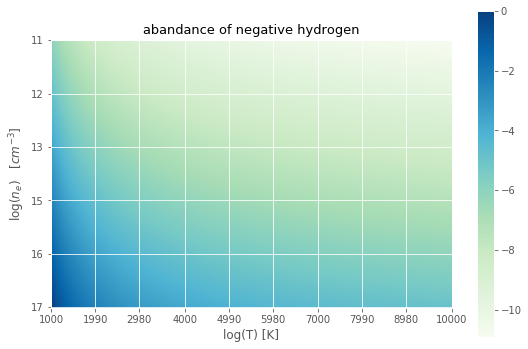

In [4]:
# 
Hm_HI.shape,T.shape
#plt.imshow(np.log10(ri))#,extent=[3,5,7,17] )
fig, ax = plt.subplots(1,1, figsize=(9,6)) #, dpi=150)
plt.imshow(np.log10(Hm_HI),cmap="GnBu")#,extent=[3,5,7,17] )
plt.colorbar()
ax.set_xlabel("log(T) [K]")
ax.set_ylabel("log($n_e$)$ \quad [cm^{-3}$]")
plt.title("abandance of negative hydrogen",fontsize=13)
from src.visual import Plotting
#Plotting.set_imshow_ticks(ax, np.log10(T),axis='x',points=9,fmt='%2.1f',rot=0)
Plotting.set_imshow_ticks(ax, T,axis='x',points=10,fmt='%4.0f',rot=0)
Plotting.set_imshow_ticks(ax, np.log10(n_e),axis='y',points=6,fmt='%1.0f',rot=0)

<font size=3>
Classical cross section for scattering by a harmonic oscillator
(RL2004)

$$ 
\sigma_\omega = \sigma_T \frac{\omega^4}{(\omega^{2} - \omega_0^{2})^2 + (\omega_0^{3}\tau)^2} ,\qquad
\sigma_T {\rm : Thomson \, scattering\, cross\, section }
$$    
</font>


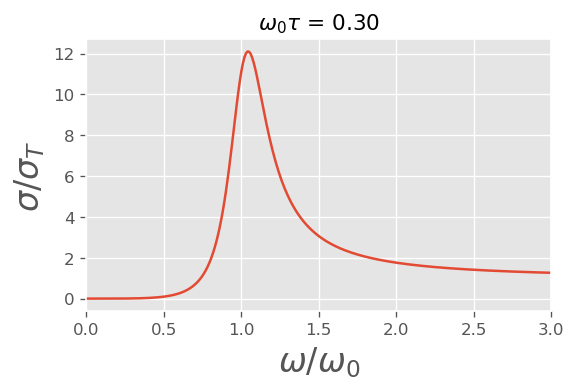

In [58]:
w = np.linspace(0, 5, 501)     # omega/omega_0
tw= [0.3] #,0.2,0.1, 0.01]
n_t = len(tw)
fig, ax = plt.subplots(1,1, figsize=(5,3), dpi=120)
for i in range(n_t):
    s = w**4/((w**2 - 1)**2 + tw[i]**2 ) #* w**4 )
    ax.plot(w,s)#, label=f"$\omega_0 \tau $={tw[i]:1.2f}")
ax.set_ylabel("$\sigma/\sigma_T$",fontsize=20)
ax.set_xlabel("$\omega/\omega_0$",fontsize=20)
ax.set_xlim(0.,3)
#plt.title("$\omega_0 τ $ ={tw[0]:1.2f}",fontsize=13)
plt.title("$\omega_0 τ $ = {0:1.2f}".format(tw[0]),fontsize=13)
#ax.set_ylim(0,4.5)
ax.legend(loc="upper right",fontsize=20)
